# E15 — Zero-Shot Forecasting, Honestly

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a real daily time series out of 25,000 raw event records — the sample of a 663,522-call log that ships with this repository — including the boundary defects nobody mentions
- Implement **naive**, **seasonal-naive**, **Holt-Winters (ETS)** and **Theta** forecasts from their formulas, in NumPy
- Score them with **MASE**, the scale-free error measure that makes "is this model any good?" answerable
- Run a **rolling-origin backtest** — the time-series equivalent of the cross-validation you learned in Course 04
- Move the evaluation window across a real structural break and watch every method's error rise together
- Read the published claims of 2026 time-series **foundation models** and state precisely what a fair comparison against them would require

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 5, lesson 09 `examples/09_model_monitoring.ipynb`, which opens with the case
"March 2020, when everybody's models broke at once" and monitors a deployed model for degradation. This
notebook uses that same break as a *measurement instrument*: the same four forecasters are scored before it
and across it, so you can see what a regime change does to an error number. It also builds on Course 04
(AIAT 114) — Unit 2, lesson 01 `examples/01_cross_validation.ipynb`: rolling-origin evaluation is
cross-validation with the one extra rule that time imposes — you may never train on data that comes after
what you are predicting.

**Used later in:** Course 11 (AIAT 125) — Unit 5, which adds drift detection and alerting on top of exactly
this kind of monitoring, and Course 12 (AIAT 126), where any project with a temporal target has to defend its
evaluation split against this objection.

> ### ⚠️ This lesson is deliberately half-runnable
> The classical baselines below run offline on CPU in seconds and every number they produce is computed live.
> The **foundation-model half cannot run here**: Chronos, Chronos-2 and TimesFM all require downloading
> pretrained weights, and this notebook has no network. Part 5 therefore presents their **published claims as
> a clearly labelled read-only comparison** and spends its effort on the more useful question — what a fair
> comparison against them would actually require. Nothing in Part 5 is a measurement made in this notebook.

## 🌍 Why this matters: forecasting stopped being a per-dataset modelling job

For thirty years, forecasting worked like this: take *your* series, choose a model, estimate *its* parameters
on *your* history, forecast. Every series got its own fitted model. The M4 competition
(Makridakis, Spiliotis & Assimakopoulos, 2020) put 100,000 series and 61 methods through that pipeline and
found that simple statistical methods — the ones you are about to implement — were extremely hard to beat.

Then pretraining arrived. Ansari et al. tokenized time-series values into a fixed vocabulary and trained
ordinary T5 language-model architectures (20M to 710M parameters) on a large collection of public series.
Their claim, in their own words: across a benchmark of 42 datasets, Chronos models have "comparable and
occasionally superior **zero-shot** performance on new datasets, relative to methods that were trained
specifically on them" ([arXiv:2403.07815](https://arxiv.org/abs/2403.07815)). *Zero-shot* means the model
never saw your series and estimated no parameters on it. In 2025 Chronos-2 extended this to multivariate and
covariate-informed forecasting and reported state-of-the-art results on three benchmarks — fev-bench,
GIFT-Eval and Chronos Benchmark II — noting that on tasks with covariates it "consistently outperforms
baselines by a wide margin" ([arXiv:2510.15821](https://arxiv.org/abs/2510.15821)).

**What goes wrong without this lesson.** Two opposite errors, and both are common.

The first is dismissing the change: continuing to fit an ARIMA per series when an inference-only model would
have been more accurate and needed no per-series fitting at all. The second is worse, and it is the reason
this notebook exists: **believing a zero-shot number without asking what it was measured against.** A
"foundation model beats the baselines" claim is only meaningful if (a) the baselines were tuned as carefully
as the foundation model, (b) the test series were genuinely absent from pretraining, and (c) the evaluation
window is representative. Point (b) is not hypothetical: the benchmark authors themselves treat leakage as
the central design problem. GIFT-Eval ships "a non-leaking pretraining dataset containing approximately 230
billion data points" precisely so that zero-shot claims can be checked
([arXiv:2410.10393](https://arxiv.org/abs/2410.10393)), and the 2026 TIME benchmark was built with "50 fresh
datasets and 98 forecasting tasks, tailored for strict zero-shot TSFM evaluation free from data leakage",
after its authors found existing benchmarks dominated by "reused legacy sources"
([arXiv:2602.12147](https://arxiv.org/abs/2602.12147)).

Your job as the engineer in the room is to be the person who asks (a), (b) and (c). The rest of this notebook
gives you the baseline you need in order to ask them credibly.

## 📥 Inputs & 📤 Outputs

**Inputs:** one real emergency-service call log from Montgomery County, Pennsylvania, timestamped from
December 2015 to July 2020. The full log is **663,522 records and 123 MB**, and it is *not* committed to this
repository; `load("montgomery_911_calls", prefer="sample")` reads the **25,000-record sample that is** — 1 call
in every 27, evenly spread across the same window. We aggregate that to a **daily call count**, which gives a
series with strong weekly seasonality and one very well-known structural break in it. Daily counts here are
therefore about a twenty-seventh of the county's real daily counts; the *shape* — weekly cycle, trend, the
March-2020 step — is what survives the thinning, and the shape is what this notebook forecasts. Every number
printed below is a number about the sample. No random numbers anywhere in this notebook.

**Outputs:** the daily series with its weekly profile; four forecasters implemented from their formulas; a
rolling-origin MASE/sMAPE table over 26 pre-2020 origins; the same table recomputed across the March-2020
break; a chart of both; and a labelled read-only summary of published foundation-model claims.

## Part 1: Building the Series — and the Two Days You Must Throw Away

Raw event logs do not arrive as time series. You make the series, and the choices you make while doing it are
part of the model whether you admit them or not.

The first and last days of this file are **partial**: the log starts mid-afternoon on the first day and stops
mid-afternoon on the last. Keep them and you have two artificially low counts at exactly the two positions a
forecaster is most sensitive to. This is not a subtlety — it is the single most common defect in
event-log-derived series, and it is invisible unless you look.

In [1]:
# WHAT: load the raw call log, aggregate to daily counts, and drop the two partial boundary days.
# WHY:  a series built from an event log inherits the log's start and end times. The first and last
#       days are truncated, and a truncated count is not a low day - it is a wrong number.
from pathlib import Path
import numpy as np
import pandas as pd

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
# HONEST NOTE: the full 911 log is 663,522 calls / 123 MB and is NOT in this repository.
#   prefer="sample" reads the 25,000-row copy that ships with it: 1 row in every 27,
#   evenly spread, covering the same 2015-12-10 to 2020-07-29 window. Daily COUNTS are
#   therefore about 1/27 of the real counts; the shape of the series - trend, weekly
#   cycle, the COVID step - is what survives, and that shape is what this notebook
#   forecasts. Every number printed below is for the sample.
raw = load("montgomery_911_calls", prefer="sample",
           usecols=["timeStamp", "title"])          # title is used in Part 4b
stamps = pd.to_datetime(raw["timeStamp"])
raw["day"] = stamps.dt.floor("D")

print(f"raw call records : {len(raw):,}")
print(f"first timestamp  : {stamps.min()}   <- mid-afternoon, so day 1 is partial")
print(f"last  timestamp  : {stamps.max()}   <- mid-afternoon, so the last day is partial")

daily_all = stamps.dt.floor("D").value_counts().sort_index()
daily = daily_all.iloc[1:-1]                       # drop both partial boundary days

print(f"\ndays before trimming : {len(daily_all):,}   (first {daily_all.iloc[0]}, last {daily_all.iloc[-1]} calls)")
print(f"days after trimming  : {len(daily):,}   ({daily.index.min().date()} to {daily.index.max().date()})")

expected_days = (daily.index.max() - daily.index.min()).days + 1
print(f"calendar days in range: {expected_days:,}  -> {'no gaps' if expected_days == len(daily) else 'GAPS PRESENT'}")

y = daily.to_numpy().astype(float)
dates = daily.index
SEASON = 7                                          # the period we will model: one week
print(f"\nmean {y.mean():.1f} calls/day, min {y.min():.0f}, max {y.max():.0f}")

montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.
raw call records : 25,000
first timestamp  : 2015-12-10 18:02:38   <- mid-afternoon, so day 1 is partial
last  timestamp  : 2020-07-29 15:52:46   <- mid-afternoon, so the last day is partial

days before trimming : 1,694   (first 4, last 9 calls)
days after trimming  : 1,692   (2015-12-11 to 2020-07-28)
calendar days in range: 1,692  -> no gaps

mean 14.8 calls/day, min 5, max 83


Average calls by day of week (this is the structure seasonal-naive gets for free):

  Monday       15.0  ##
  Tuesday      15.2  ##
  Wednesday    15.4  ##
  Thursday     15.4  ##
  Friday       16.1  ##
  Saturday     13.9  ##
  Sunday       12.3  ##

Busiest day is 31% above the quietest. A model that ignores this is throwing away
the single most predictable thing about the series.


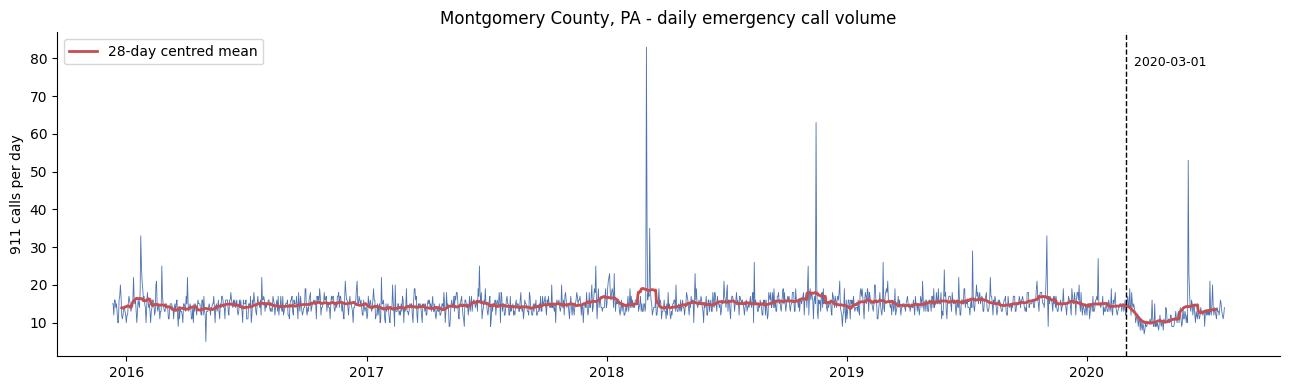

In [2]:
# WHAT: show the weekly profile and plot the whole series, marking the two windows we will evaluate on.
# WHY:  before choosing a model, look at the data. The weekly shape is what seasonal-naive exploits;
#       the visible level change in March 2020 is what Part 4 is built around.
import matplotlib.pyplot as plt        # the notebook kernel renders figures inline; no window is opened

profile = pd.DataFrame({"calls": y, "weekday": dates.day_name(), "dow": dates.dayofweek})
weekly = profile.groupby(["dow", "weekday"], observed=True)["calls"].mean().reset_index()
print("Average calls by day of week (this is the structure seasonal-naive gets for free):\n")
for _, r in weekly.iterrows():
    bar = "#" * int(round(r["calls"] / 8))
    print(f"  {r['weekday']:<10s} {r['calls']:6.1f}  {bar}")
swing = weekly['calls'].max() / weekly['calls'].min() - 1
print(f"\nBusiest day is {swing:.0%} above the quietest. A model that ignores this is throwing away")
print("the single most predictable thing about the series.")

BREAK_DATE = pd.Timestamp("2020-03-01")
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(dates, y, lw=0.6, color="#4C72B0")
ax.plot(dates, pd.Series(y).rolling(28, center=True).mean(), lw=2, color="#C44E52",
        label="28-day centred mean")
ax.axvline(BREAK_DATE, color="black", ls="--", lw=1)
ax.text(BREAK_DATE, y.max() * 0.97, "  2020-03-01", fontsize=9, va="top")
ax.set_ylabel("911 calls per day"); ax.set_title(
    "Montgomery County, PA - daily emergency call volume")
ax.legend(loc="upper left"); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## Part 2: Four Forecasters, Written Out From Their Formulas

`statsmodels` is not installed in this environment, and that is convenient: you are going to write these
yourself, which is the only way to know what they actually assume.

| method | what it assumes | parameters fitted |
|---|---|---|
| **Naive** | tomorrow looks like today | none |
| **Seasonal naive** | this Tuesday looks like last Tuesday | none |
| **Holt-Winters (ETS additive)** | level + linear trend + additive weekly pattern, all updated by exponential smoothing | α, β, γ |
| **Theta** | a deseasonalized series is exponential smoothing plus half its long-run drift | α (plus a regression slope) |

The Theta method won the M3 competition and is the standard "surprisingly hard to beat" benchmark. Hyndman
and Billah proved it is equivalent to simple exponential smoothing with a drift term of half the slope of a
linear regression through the data — which is why it fits in fifteen lines here.

In [3]:
# WHAT: implement the two parameter-free baselines.
# WHY:  every forecasting claim you will ever read is implicitly a claim to beat these. Write them
#       first, so you always have something to be beaten by.
def forecast_naive(train, horizon):
    """Repeat the last observed value."""
    return np.full(horizon, train[-1])

def forecast_seasonal_naive(train, horizon, m=SEASON):
    """Repeat the last observed season. Day T+k copies the same weekday from the final week."""
    last_season = train[-m:]
    return np.array([last_season[k % m] for k in range(horizon)])

print("naive           ->", forecast_naive(y[:100], 7).round(1))
print("seasonal naive  ->", forecast_seasonal_naive(y[:100], 7).round(1))
print("actual next 7   ->", y[100:107].round(1))

naive           -> [12. 12. 12. 12. 12. 12. 12.]
seasonal naive  -> [11. 14. 15. 13. 15. 16. 12.]
actual next 7   -> [ 9. 14. 11. 14. 13. 13. 12.]


In [4]:
# WHAT: Holt-Winters additive (ETS) - level, trend and seasonal states updated every step, with the
#       three smoothing parameters fitted by minimising in-sample squared error.
# WHY:  this is the workhorse the whole industry ran on before 2024, and seeing the three update
#       equations written out is the difference between using it and quoting it.
from scipy.optimize import minimize, minimize_scalar

def _holt_winters_states(train, alpha, beta, gamma, m=SEASON):
    """Run the additive Holt-Winters recursions; return final level, trend and seasonal buffer."""
    level = train[:m].mean()
    trend = 0.0
    seasonal = list(train[:m] - level)          # crude but standard initialisation
    sse = 0.0
    for t in range(m, len(train)):
        s_t = seasonal[t - m]
        sse += (train[t] - (level + trend + s_t)) ** 2      # one-step-ahead in-sample error
        prev_level = level
        level = alpha * (train[t] - s_t) + (1 - alpha) * (level + trend)
        trend = beta * (level - prev_level) + (1 - beta) * trend
        seasonal.append(gamma * (train[t] - level) + (1 - gamma) * s_t)
    return level, trend, seasonal, sse

def forecast_holt_winters(train, horizon, m=SEASON):
    """Fit alpha, beta, gamma on the training data, then extrapolate level + trend + season."""
    fit = minimize(lambda p: _holt_winters_states(train, *p, m)[3],
                   x0=[0.2, 0.02, 0.2], bounds=[(0.01, 0.99)] * 3, method="L-BFGS-B")
    level, trend, seasonal, _ = _holt_winters_states(train, *fit.x, m)
    return np.array([level + k * trend + seasonal[len(train) - m + ((k - 1) % m)]
                     for k in range(1, horizon + 1)]), fit.x

fc, params = forecast_holt_winters(y[:400], 7)
print(f"fitted alpha={params[0]:.3f}  beta={params[1]:.3f}  gamma={params[2]:.3f}")
print("holt-winters ->", fc.round(1))
print("actual       ->", y[400:407].round(1))

fitted alpha=0.085  beta=0.010  gamma=0.059
holt-winters -> [14.4 12.5 14.8 15.9 15.6 15.4 16.2]
actual       -> [11. 12. 12. 15. 12. 14. 15.]


In [5]:
# WHAT: the Theta method - deseasonalise, run SES, add half the regression slope back as drift,
#       then reseasonalise.
# WHY:  it is the benchmark that embarrassed a generation of complicated models, and it is short
#       enough that there is nowhere for magic to hide.
def forecast_theta(train, horizon, m=SEASON):
    """Classical Theta: SES on the deseasonalised series with drift = half the regression slope."""
    n = len(train)
    t = np.arange(n)

    # 1. additive seasonal indices, taken from the residuals of a linear trend
    slope_intercept = np.polyfit(t, train, 1)
    residual = train - np.polyval(slope_intercept, t)
    season = np.array([residual[t % m == k].mean() for k in range(m)])
    season = season - season.mean()                 # indices must sum to zero
    deseasonalised = train - season[t % m]

    # 2. simple exponential smoothing on the deseasonalised series; alpha by in-sample SSE
    def ses_sse(alpha):
        level, sse = deseasonalised[0], 0.0
        for value in deseasonalised[1:]:
            sse += (value - level) ** 2
            level = alpha * value + (1 - alpha) * level
        return sse
    alpha = minimize_scalar(ses_sse, bounds=(0.01, 0.99), method="bounded").x

    level = deseasonalised[0]
    for value in deseasonalised[1:]:
        level = alpha * value + (1 - alpha) * level

    # 3. drift is HALF the slope of the deseasonalised series (Hyndman & Billah, 2003)
    b = np.polyfit(t, deseasonalised, 1)[0]
    out = []
    for k in range(1, horizon + 1):
        drift = (b / 2) * (k - 1 + 1 / alpha - (1 - alpha) ** n / alpha)
        out.append(level + drift + season[(n + k - 1) % m])       # 4. reseasonalise
    return np.array(out), alpha

fc, alpha = forecast_theta(y[:400], 7)
print(f"fitted alpha={alpha:.3f}")
print("theta  ->", fc.round(1))
print("actual ->", y[400:407].round(1))

fitted alpha=0.131
theta  -> [14.3 12.8 15.2 16.  15.8 15.6 16. ]
actual -> [11. 12. 12. 15. 12. 14. 15.]


## Part 3: Rolling-Origin Backtesting and MASE

**MASE** (Hyndman & Koehler, 2006) divides your mean absolute error by the mean absolute error of a
**seasonal-naive forecast made in-sample**. That makes it scale-free and gives it a reading you can memorise:

- **MASE < 1** — you beat the naive seasonal forecast on this window.
- **MASE = 1** — you matched it.
- **MASE > 1** — you would have done better by copying last week.

**Rolling origin** is the time-series version of cross-validation from Course 04, Unit 2, with one rule added:
the training data always ends before the test data begins. We use 26 origins spaced two weeks apart, each
forecasting 14 days ahead, all of them ending before March 2020.

In [6]:
# WHAT: define MASE and sMAPE, then run the rolling-origin backtest over the pre-2020 period.
# WHY:  one train/test split of a time series tells you about one fortnight. Twenty-six of them tell
#       you about the method. This is the honest minimum for any temporal claim.
def mase(actual, predicted, train, m=SEASON):
    """Mean absolute error scaled by the in-sample seasonal-naive MAE of the SAME training window."""
    scale = np.mean(np.abs(train[m:] - train[:-m]))
    return float(np.mean(np.abs(actual - predicted)) / scale)

def smape(actual, predicted):
    """Symmetric MAPE in percent; reported alongside MASE because reviewers still ask for it."""
    return float(200 * np.mean(np.abs(actual - predicted) / (np.abs(actual) + np.abs(predicted))))

HORIZON = 14
METHODS = {
    "naive": lambda tr, h: forecast_naive(tr, h),
    "seasonal naive": lambda tr, h: forecast_seasonal_naive(tr, h),
    "Holt-Winters": lambda tr, h: forecast_holt_winters(tr, h)[0],
    "Theta": lambda tr, h: forecast_theta(tr, h)[0],
}

def backtest(origins):
    """For each origin: train on everything before it, forecast HORIZON days, score every method."""
    records = []
    for origin in origins:
        train, actual = y[:origin], y[origin:origin + HORIZON]
        if len(actual) < HORIZON:
            continue
        row = {"origin": dates[origin].date()}
        for name, fn in METHODS.items():
            prediction = fn(train, HORIZON)
            row[f"{name} MASE"] = mase(actual, prediction, train)
            row[f"{name} sMAPE"] = smape(actual, prediction)
        records.append(row)
    return pd.DataFrame(records)

break_index = int(np.where(dates >= BREAK_DATE)[0][0])
pre_origins = [break_index - k * HORIZON for k in range(26, 0, -1)]

pre = backtest(pre_origins)
print(f"{len(pre)} origins, {dates[pre_origins[0]].date()} to {dates[pre_origins[-1]].date()}, "
      f"horizon {HORIZON} days, all before the break\n")

summary_pre = pd.DataFrame({
    "mean MASE": [pre[f"{m} MASE"].mean() for m in METHODS],
    "median MASE": [pre[f"{m} MASE"].median() for m in METHODS],
    "worst MASE": [pre[f"{m} MASE"].max() for m in METHODS],
    "mean sMAPE %": [pre[f"{m} sMAPE"].mean() for m in METHODS],
    "origins won": [int(sum(pre[[f'{k} MASE' for k in METHODS]].idxmin(axis=1) == f"{m} MASE"))
                    for m in METHODS],
}, index=list(METHODS))

print(summary_pre.to_string(float_format=lambda v: f"{v:8.3f}"))
best = summary_pre["mean MASE"].idxmin()
print(f"\nBest mean MASE: {best} at {summary_pre.loc[best, 'mean MASE']:.3f}.")
print(f"Seasonal naive - which fits nothing at all - scores {summary_pre.loc['seasonal naive', 'mean MASE']:.3f}.")
print(f"So the two fitted models buy about "
      f"{1 - summary_pre.loc[best, 'mean MASE'] / summary_pre.loc['seasonal naive', 'mean MASE']:.0%} "
      f"over copying last week.")

26 origins, 2019-03-03 to 2020-02-16, horizon 14 days, all before the break

                mean MASE  median MASE  worst MASE  mean sMAPE %  origins won
naive               1.189        1.005       5.626        17.101            2
seasonal naive      0.839        0.746       1.533        12.046            3
Holt-Winters        0.633        0.595       1.190         9.171           11
Theta               0.628        0.589       1.192         9.090           10

Best mean MASE: Theta at 0.628.
Seasonal naive - which fits nothing at all - scores 0.839.
So the two fitted models buy about 25% over copying last week.


## Part 4: The Experiment — Change the Window, Not the Model

**Baseline.** The table you just read: 26 origins, all ending before 1 March 2020.

**Change one thing.** The *evaluation window*. We move it forward so the origins sit on and after the break.
Identical code, identical methods, identical horizon, identical metric. The only difference is *when* we asked
the question.

**Re-run and read the numbers.** If a forecast accuracy number were a property of the model, nothing should
change.

In [7]:
# WHAT: re-run the identical backtest on origins that start at the break and continue to the end of
#       the data, then compare the two windows side by side.
# WHY:  this is the whole argument. An error number is a statement about a model AND a period, and
#       reporting it without the period is reporting half a result.
post_origins = [break_index + k * HORIZON for k in range(0, 10)]
post = backtest(post_origins)
print(f"{len(post)} origins, {post['origin'].iloc[0]} to {post['origin'].iloc[-1]}, "
      f"spanning the break\n")

comparison = pd.DataFrame({
    "mean MASE before": [pre[f"{m} MASE"].mean() for m in METHODS],
    "mean MASE across": [post[f"{m} MASE"].mean() for m in METHODS],
}, index=list(METHODS))
comparison["change"] = comparison["mean MASE across"] / comparison["mean MASE before"] - 1
print(comparison.to_string(formatters={
    "mean MASE before": "{:8.3f}".format, "mean MASE across": "{:8.3f}".format,
    "change": "{:+8.0%}".format}))

pre_level = y[break_index - 56:break_index].mean()
post_level = y[break_index:break_index + 56].mean()
print(f"\nThe level itself moved: {pre_level:.0f} calls/day in the eight weeks before the break, "
      f"{post_level:.0f} after")
print(f"- a fall of {1 - post_level / pre_level:.0%}.")

print("\nPer-origin MASE across the break (Theta), worst first:")
worst = post[["origin", "Theta MASE", "seasonal naive MASE"]].sort_values("Theta MASE", ascending=False)
print(worst.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

print(f"\nCONCLUSION SUPPORTED BY THESE NUMBERS:")
print(f"  Not one line of model code changed between the two columns; only the calendar did.")
for name in ("seasonal naive", "Holt-Winters", "Theta"):
    print(f"    {name:<15s} {comparison.loc[name, 'mean MASE before']:.3f} -> "
          f"{comparison.loc[name, 'mean MASE across']:.3f}  ({comparison.loc[name, 'change']:+.0%})")
print(f"  Plain naive is the exception ({comparison.loc['naive', 'change']:+.0%}): it never used the weekly")
print(f"  pattern, so it had none to lose, and MASE's own denominator grew with the disruption.")
print(f"  The best mean MASE across the break is {comparison['mean MASE across'].min():.3f} - worse than")
print(f"  seasonal naive managed BEFORE it ({comparison.loc['seasonal naive', 'mean MASE before']:.3f}).")
print(f"  Every bit of the fitted models' advantage is gone.")
print(f"  A forecast accuracy figure is a statement about a model AND a period. Quote both.")

10 origins, 2020-03-01 to 2020-07-05, spanning the break

               mean MASE before mean MASE across   change
naive                     1.189            1.095      -8%
seasonal naive            0.839            1.349     +61%
Holt-Winters              0.633            1.064     +68%
Theta                     0.628            1.036     +65%

The level itself moved: 15 calls/day in the eight weeks before the break, 11 after
- a fall of 23%.

Per-origin MASE across the break (Theta), worst first:
    origin  Theta MASE  seasonal naive MASE
2020-05-24       2.367                2.315
2020-03-15       2.151                2.069
2020-06-07       1.456                4.128
2020-07-05       0.928                0.944
2020-04-12       0.656                0.955
2020-03-29       0.636                0.698
2020-05-10       0.617                0.513
2020-03-01       0.560                0.635
2020-06-21       0.516                0.533
2020-04-26       0.467                0.702

CONCLUSION

### Part 4b: The Days No Forecaster Could Have Seen Coming

A structural break is a shift in the *level*. The other thing that wrecks a forecast is a single day that
does not belong to the distribution at all. Find them, look at what they were, and be honest about whether a
better model would have helped.

In [8]:
# WHAT: find the largest daily counts in the whole series and break the biggest one down by call type.
# WHY:  before blaming the model, check whether the information needed was even in the series. Here it
#       was not - the answer is in the weather, and the weather is not a column we have.
extremes = daily.nlargest(5)
typical = daily.median()
print(f"typical day: {typical:.0f} calls\n")
print("five largest days in the whole series:")
for day, count in extremes.items():
    print(f"  {day.date()}  {count:5,} calls   {count / typical:4.1f}x a typical day")

worst_day = extremes.index[0]
titles = raw.loc[raw["day"] == worst_day, "title"].value_counts().head(5)
print(f"\nWhat those {extremes.iloc[0]:,} calls on {worst_day.date()} actually were:")
for label, n in titles.items():
    print(f"  {n:5,}  {label}")
print("\nRoad obstructions, vehicle accidents and outdoor electrical fires, all at once: the signature")
print("of a severe storm bringing down trees onto power lines. No amount of past call volume predicts")
print("that. A covariate-informed model with a weather feed might; a univariate forecaster cannot.")
print(f"\nNote also that this day sits in {worst_day.year}, well inside our 'clean' pre-break window.")
print("Outliers are not something that only happens during a crisis.")

typical day: 15 calls

five largest days in the whole series:
  2018-03-02     83 calls    5.5x a typical day
  2018-11-15     63 calls    4.2x a typical day
  2020-06-03     53 calls    3.5x a typical day
  2018-03-07     35 calls    2.3x a typical day
  2018-03-03     34 calls    2.3x a typical day

What those 83 calls on 2018-03-02 actually were:
     33  Traffic: ROAD OBSTRUCTION -
     16  Traffic: VEHICLE ACCIDENT -
      9  Fire: ELECTRICAL FIRE OUTSIDE
      6  Traffic: DISABLED VEHICLE -
      2  EMS: VEHICLE ACCIDENT

Road obstructions, vehicle accidents and outdoor electrical fires, all at once: the signature
of a severe storm bringing down trees onto power lines. No amount of past call volume predicts
that. A covariate-informed model with a weather feed might; a univariate forecaster cannot.

Note also that this day sits in 2018, well inside our 'clean' pre-break window.
Outliers are not something that only happens during a crisis.


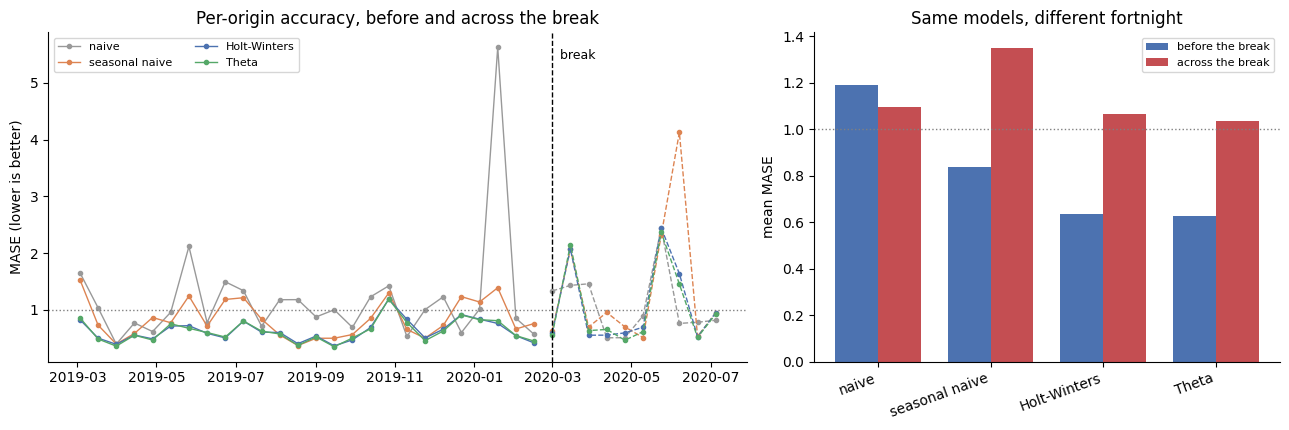

In [9]:
# WHAT: plot the two windows on one axis so the comparison is not a table of numbers.
# WHY:  the story is a step change, and a step change is a picture.
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.4), gridspec_kw={"width_ratios": [1.5, 1]})

for name, colour in zip(METHODS, ["#999999", "#DD8452", "#4C72B0", "#55A868"]):
    axA.plot(pd.to_datetime(pre["origin"]), pre[f"{name} MASE"], "o-", ms=3, lw=1,
             color=colour, label=name)
    axA.plot(pd.to_datetime(post["origin"]), post[f"{name} MASE"], "o--", ms=3, lw=1, color=colour)
axA.axvline(BREAK_DATE, color="black", ls="--", lw=1)
axA.axhline(1.0, color="grey", ls=":", lw=1)
axA.text(BREAK_DATE, axA.get_ylim()[1] * 0.95, "  break", fontsize=9, va="top")
axA.set_ylabel("MASE (lower is better)"); axA.set_title("Per-origin accuracy, before and across the break")
axA.legend(fontsize=8, ncol=2); axA.spines[["top", "right"]].set_visible(False)

x = np.arange(len(METHODS)); width = 0.38
axB.bar(x - width / 2, comparison["mean MASE before"], width, label="before the break", color="#4C72B0")
axB.bar(x + width / 2, comparison["mean MASE across"], width, label="across the break", color="#C44E52")
axB.axhline(1.0, color="grey", ls=":", lw=1)
axB.set_xticks(x, list(METHODS), rotation=20, ha="right")
axB.set_ylabel("mean MASE"); axB.set_title("Same models, different fortnight")
axB.legend(fontsize=8); axB.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 💬 Discuss

1. Every method got worse across the break, and the two *fitted* methods lost more than the two
   parameter-free ones. Does that mean fitting was a mistake? Argue both sides using the per-origin table,
   then say what you would actually deploy for March 2020 if you had to choose on 28 February.
2. We chose 1 March 2020 as the break because we already know what happened. Your own project will not have
   that luxury. What would you have had to monitor, in the first two weeks of March, to detect the break
   *without* knowing the cause — and what would you have done about it? (Course 05, Unit 5, lesson 09 is where
   that machinery lives.)
3. Suppose a vendor shows you a zero-shot foundation model scoring MASE 0.55 on this exact dataset. Name
   three things you would need to see before you accepted that as better than the **0.628** you computed
   above — at least one of which is about the *dataset*, not the model. (Start with the obvious one: did they
   run on the 25,000-record sample or on the full 663,522-record log? Those are different series.)

## Part 5: The Half This Notebook Cannot Run

> ### 📋 READ-ONLY COMPARISON — published claims, not measurements made here
> Everything in this section is quoted from the papers cited beside it. **No foundation model was run in this
> notebook**, and none can be: Chronos ships T5-family checkpoints of 20M–710M parameters, Chronos-2 and
> TimesFM likewise require downloading pretrained weights, and this lesson has no network access and a
> two-minute CPU budget. Treat the table below as literature, not as evidence produced here.

| model / benchmark | year | what its authors report | id |
|---|---|---|---|
| **Chronos** | 2024 | Tokenizes values into a fixed vocabulary and trains T5 architectures (20M–710M params) on public + synthetic series. On 42 datasets: significantly better on in-corpus data, and "comparable and occasionally superior **zero-shot** performance on new datasets, relative to methods that were trained specifically on them" | [2403.07815](https://arxiv.org/abs/2403.07815) |
| **GIFT-Eval** | 2024 | A shared benchmark so zero-shot claims can be compared: 23 datasets, 144,000 series, 177 million points, 7 domains, 10 frequencies, plus **a non-leaking pretraining corpus of ~230 billion points**; 17 baselines analysed | [2410.10393](https://arxiv.org/abs/2410.10393) |
| **Chronos-2** | 2025 | One model for univariate, multivariate **and covariate-informed** forecasting, zero-shot, via a group-attention in-context-learning mechanism. Reports state-of-the-art on fev-bench, GIFT-Eval and Chronos Benchmark II; on covariate tasks "consistently outperforms baselines by a wide margin" | [2510.15821](https://arxiv.org/abs/2510.15821) |
| **TIME** | 2026 | Argues existing forecasting benchmarks suffer from "constrained data composition dominated by reused legacy sources, compromised data integrity, misaligned task formulations, and rigid analysis perspectives". Introduces 50 **fresh** datasets and 98 tasks "for strict zero-shot TSFM evaluation free from data leakage", and evaluates 12 foundation models | [2602.12147](https://arxiv.org/abs/2602.12147) |

### What a fair comparison would require — and why ours would fail one of the tests

Read those four rows together and the methodology falls out. If you wanted to publish "Chronos-2 beats Theta
on Montgomery County 911 calls", you would need all four of these:

1. **The same evaluation protocol for both.** Same origins, same horizon, same metric, same scaling. Our
   Part 3 protocol is reusable as-is — that is the point of writing it out.
2. **Baselines tuned as hard as the challenger.** Our Holt-Winters fits three parameters by L-BFGS-B on
   in-sample SSE with a crude initialisation. That is a *reasonable* baseline, not a *maximal* one. Any
   comparison that treats a lightly-tuned classical model as "the classical state of the art" is measuring
   effort, not method.
3. **Proof the test series was not in pretraining.** Here is where our own dataset disqualifies itself: the
   Montgomery County 911 file is a long-standing, widely mirrored public dataset. We have no way to
   demonstrate it was absent from any model's pretraining corpus — which is exactly the failure mode GIFT-Eval
   built a non-leaking corpus to avoid and TIME built 50 fresh datasets to escape. **On this dataset, a
   zero-shot claim is unfalsifiable**, and the correct response to a vendor demo on it is to ask for a series
   that did not exist when the model was trained.
4. **A window that is representative.** Part 4 showed the same models scoring 0.6 and 1.1 on the same series
   depending only on which fortnight you pick. A single-window comparison is a coin toss with extra steps.

**The honest summary for a 2026 practitioner:** pretrained forecasters are a real and useful change, and for a
new series with no history to fit on they are often the fastest route to a decent forecast. They are also
evaluated on benchmarks their own authors describe as leak-prone, against baselines that are frequently
under-tuned. Compute your seasonal-naive and Theta numbers first — they cost seconds — and make the foundation
model beat *those*, on *your* series, over *several* windows.

## ✅ Summary

**What you actually did here** — every figure below was printed above:

- Turned 25,000 raw call records — the bundled sample of a 663,522-call log — into a 1,692-day series,
  after discarding two partial boundary days
- Measured the weekly cycle directly: the busiest weekday runs 31% above the quietest
- Implemented naive, seasonal-naive, Holt-Winters and Theta from their formulas in NumPy, with no `statsmodels`
- Backtested over 26 rolling origins before March 2020: Theta 0.628 mean MASE, Holt-Winters 0.633,
  seasonal naive 0.839, naive 1.189 — the fitted models buy about **25%** over copying last week
- Moved the window across the March-2020 break and re-ran identical code: Theta went to **1.036** (+65%),
  Holt-Winters to **1.064** (+68%), and both lost their edge over seasonal naive entirely
- Found the series' worst day — **83 calls on 2018-03-02**, 5.5× a typical day and dominated by road
  obstructions and outdoor electrical fires — and established that no univariate model could have predicted it
- Wrote down what a fair comparison against a zero-shot foundation model would require, and found that this
  dataset fails one of the four tests before any model is run

**The one sentence to keep:** *a forecasting accuracy number describes a model, a horizon and a period* —
drop any of the three and the number stops meaning anything.

**Where this goes next:** the rolling-origin harness in Part 3 is the reusable artifact. Point it at your own
series, get the four baseline numbers, and only then evaluate anything more complicated — including a
foundation model, if you can obtain one and can defend the leakage question.

## ⚠️ Where this breaks

**Our "structural break" is one event in one county.** March 2020 is the cleanest natural experiment in
recent operational data, which is exactly why it is over-used. A method that degrades on a pandemic may be
perfectly robust to the breaks your system will actually see, and vice versa. One break is an anecdote.

**Daily counts hide the failure that matters.** Part 4b printed it: 2018-03-02 shows 83 calls in the sample
against a typical day of 15 — a 5.5× day, which in the full log is roughly 2,200 calls against about 400 —
dominated by road obstructions, vehicle accidents and outdoor electrical fires. No forecaster in
this notebook could have predicted that from history, because the information needed was weather, not past
call volume. This is the honest ceiling on *univariate* forecasting, and it is the strongest argument for the
covariate-informed models Chronos-2 targets — which, again, we cannot run here.

**Our Holt-Winters is a reasonable implementation, not a strong one.** Crude seasonal initialisation, no
damping, no Box-Cox, no automatic model selection across the ETS family, and parameters fitted by minimising
in-sample one-step SSE rather than a horizon-matched loss. A serious `statsmodels` or R `forecast` fit would
likely do better. Every comparative number in Part 3 should be read with that in mind — including the 25%
advantage over seasonal naive, which is a lower bound on what tuned classical methods can do.

**Every number here is a number about a 1-in-27 sample.** The daily counts average about 15 rather than about
400, so day-to-day variation is a larger *fraction* of the level than in the full log, and the four methods are
being scored on a noisier series than the county actually runs. MASE is scale-free, so the comparison between
methods holds; the absolute values would move if you downloaded the full file and re-ran the identical code.

**MASE has a denominator, and denominators can be gamed.** It is scaled by the in-sample seasonal-naive MAE of
whichever training window you happened to use. Change the training window and the same forecast gets a
different MASE. That is why Part 3 reports mean, median *and* worst across 26 origins rather than one number.

**And Part 5 is literature, not evidence.** We did not run a single foundation model. Everything in that
table is a published claim, correctly attributed and correctly labelled — and published claims are exactly
what this notebook is training you to interrogate. If you would not accept our numbers without the protocol,
do not accept theirs either.

## 📚 References

The classical baselines, in their original sources:

1. Assimakopoulos, V., & Nikolopoulos, K. (2000). *The theta model: a decomposition approach to forecasting*. International Journal of Forecasting 16(4), 521–530. [doi:10.1016/S0169-2070(00)00066-2](https://doi.org/10.1016/S0169-2070(00)00066-2)
2. Hyndman, R. J., & Billah, B. (2003). *Unmasking the Theta method*. International Journal of Forecasting 19(2), 287–290. [doi:10.1016/S0169-2070(01)00143-1](https://doi.org/10.1016/S0169-2070(01)00143-1) — the equivalence to SES-with-drift implemented in Part 2.
3. Hyndman, R. J., & Koehler, A. B. (2006). *Another look at measures of forecast accuracy*. International Journal of Forecasting 22(4), 679–688. [doi:10.1016/j.ijforecast.2006.03.001](https://doi.org/10.1016/j.ijforecast.2006.03.001) — the source of MASE.
4. Makridakis, S., Spiliotis, E., & Assimakopoulos, V. (2020). *The M4 Competition: 100,000 time series and 61 forecasting methods*. International Journal of Forecasting 36(1), 54–74. [doi:10.1016/j.ijforecast.2019.04.014](https://doi.org/10.1016/j.ijforecast.2019.04.014) — why simple methods are the benchmark to beat.

The zero-shot literature discussed in Part 5 (read-only; nothing below was run here):

5. Ansari, A. F., Stella, L., Turkmen, C., Zhang, X., Mercado, P., et al. (2024). *Chronos: Learning the Language of Time Series*. [arXiv:2403.07815](https://arxiv.org/abs/2403.07815)
6. Aksu, T., Woo, G., Liu, J., Liu, X., Liu, C., Savarese, S., Xiong, C., & Sahoo, D. (2024). *GIFT-Eval: A Benchmark For General Time Series Forecasting Model Evaluation*. [arXiv:2410.10393](https://arxiv.org/abs/2410.10393)
7. Ansari, A. F., Shchur, O., Küken, J., Auer, A., Han, B., et al. (2025). *Chronos-2: From Univariate to Universal Forecasting*. [arXiv:2510.15821](https://arxiv.org/abs/2510.15821)
8. Qiao, Z., Pan, S., Wang, A., Zhukova, V., Liu, Y., et al. (2026). *It's TIME: Towards the Next Generation of Time Series Forecasting Benchmarks*. [arXiv:2602.12147](https://arxiv.org/abs/2602.12147)